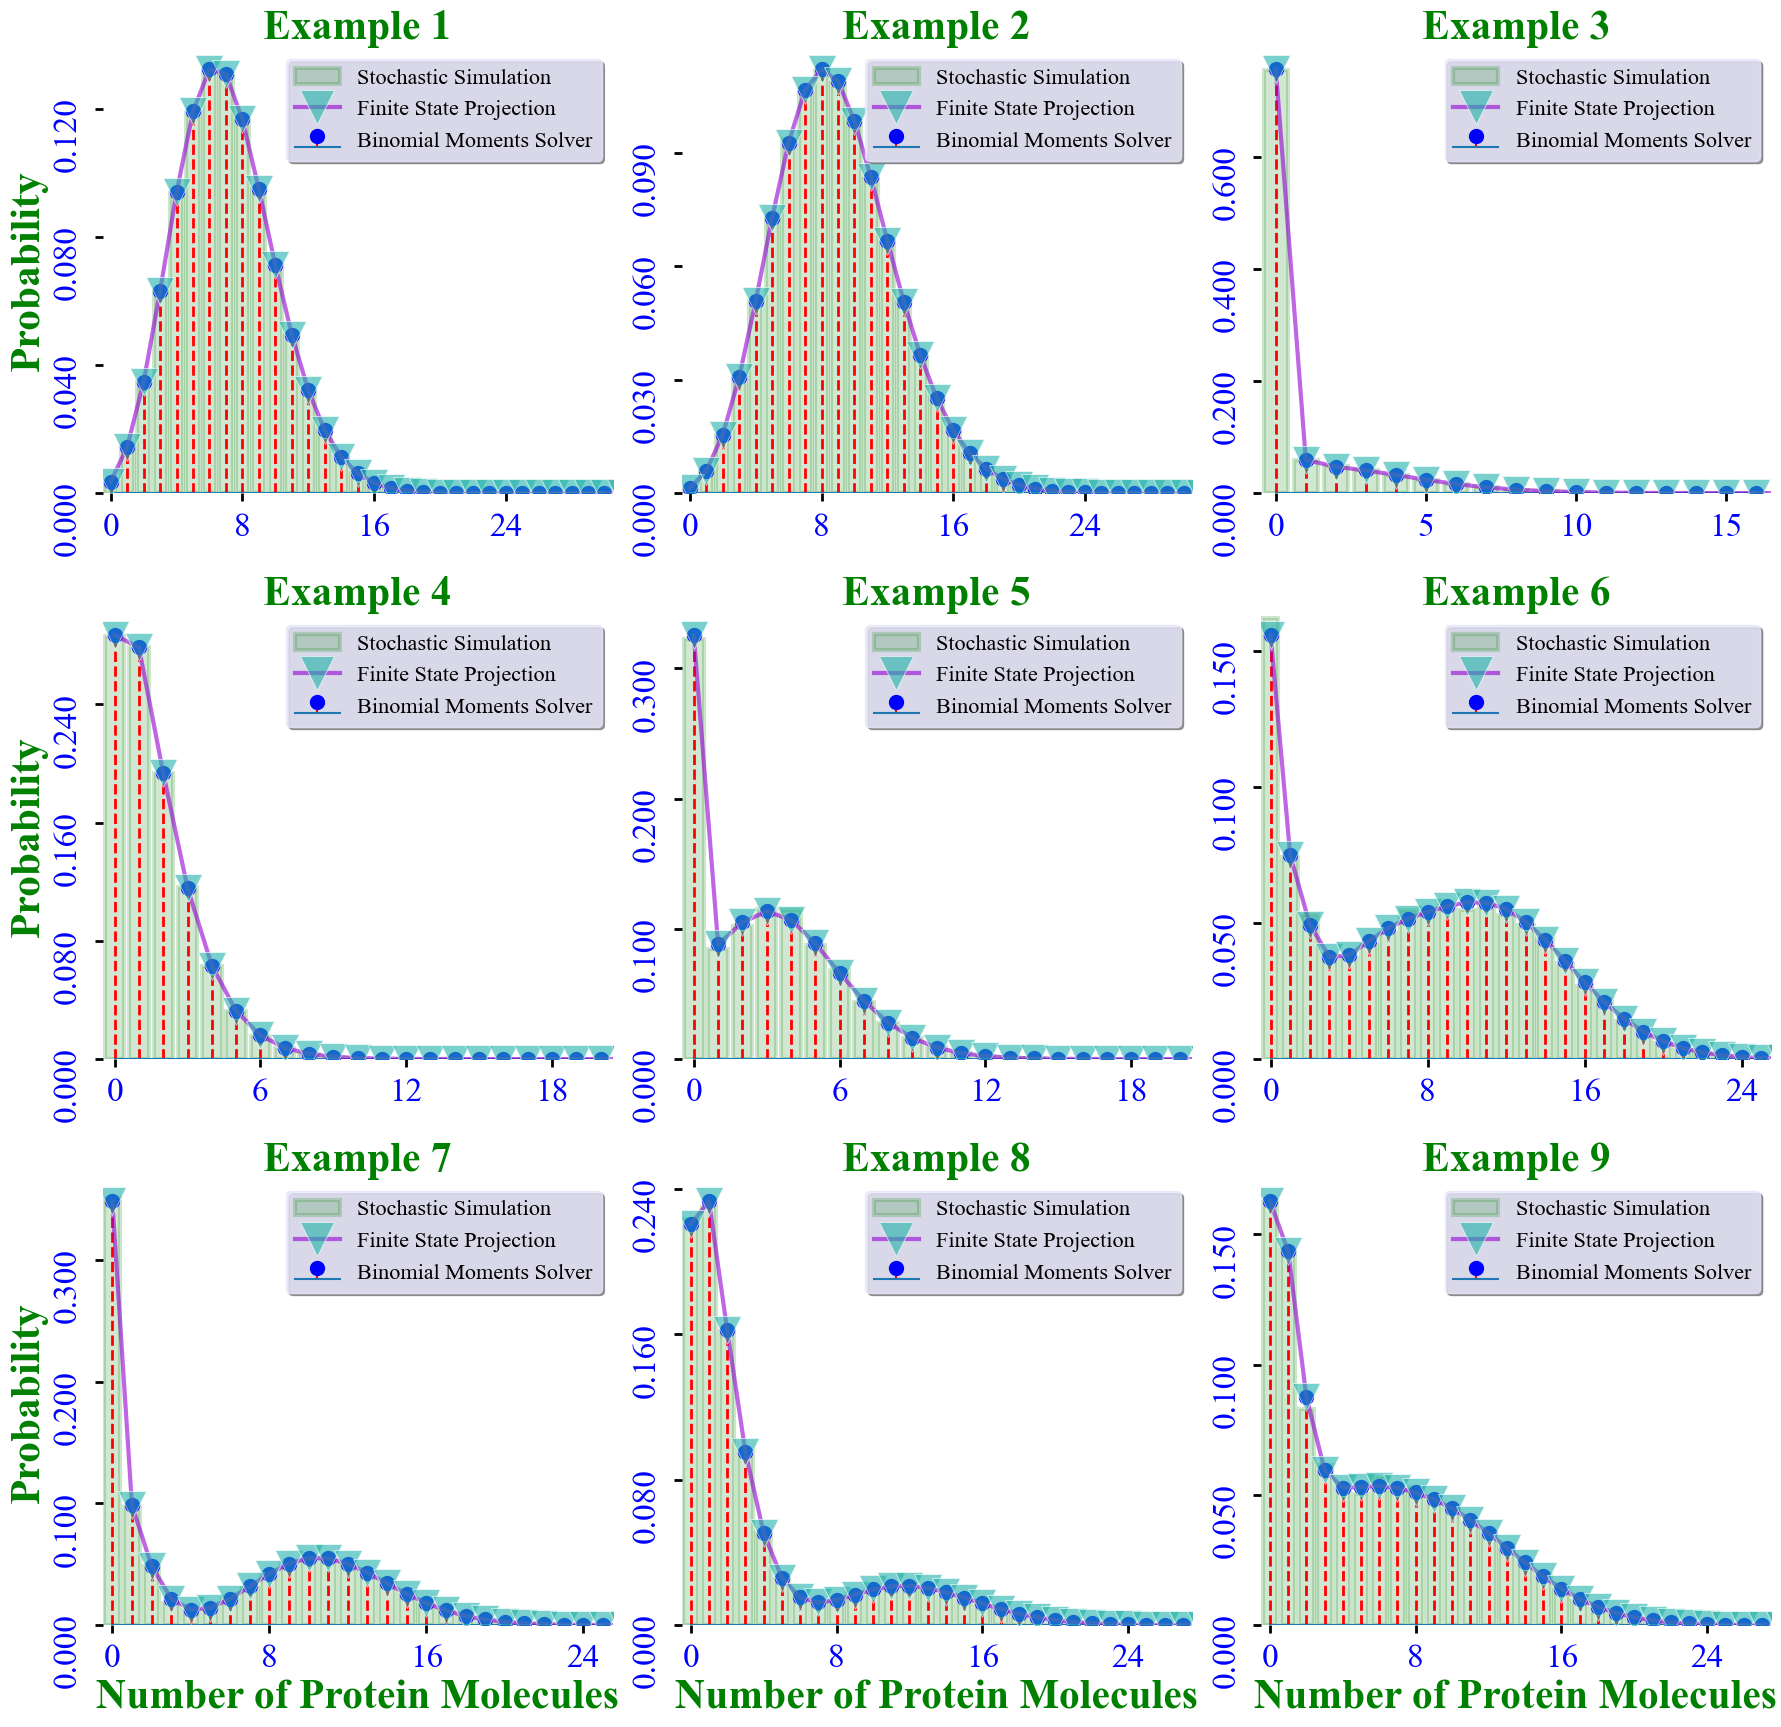

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter, MaxNLocator

base_dir = Path.cwd()

binomial_dir = base_dir / 'binomial_moments_solver'
fsp_dir = base_dir / 'fsp_results'
ssa_dir = base_dir / 'ssa_outputs'

plt.rcParams['axes.linewidth'] = 2

fig, axes = plt.subplots(3, 3, figsize=(18, 18), dpi=100)
axes = axes.flatten()

for i in range(1, 10):
    ax = axes[i - 1]

    Protein_number = np.load(
        ssa_dir / f'Protein_Number_Burst{i}.npy'
    )

    prob = np.load(
        binomial_dir / f'PMF{i}.npy'
    ).flatten()

    FSP = np.load(
        fsp_dir / f'FSP{i}.npy'
    ).flatten()

    x = np.arange(len(prob))

    markerline, stemlines, baseline = ax.stem(
        x,
        prob,
        linefmt='r--',
        markerfmt='bo',
        basefmt='',
        label='Binomial Moments Solver'
    )

    plt.setp(markerline, markersize=10)
    plt.setp(stemlines, linewidth=2)

    max_number = np.max(Protein_number)
    min_number = np.min(Protein_number)

    ax.hist(
        Protein_number,
        bins=np.arange(min_number - 0.5, max_number + 1.5, 1),
        rwidth=0.8,
        density=True,
        color='#228B22',
        edgecolor='green',
        alpha=0.2,
        linewidth=3,
        align='mid',
        label='Stochastic Simulation'
    )

    x_fsp = np.arange(len(FSP))

    sns.lineplot(
        x=x_fsp,
        y=FSP,
        ax=ax,
        label='Finite State Projection',
        color='#9400D3',
        linestyle='-',
        marker='v',
        markerfacecolor='#20B2AA',
        markersize=20,
        linewidth=3,
        alpha=0.6
    )

    ax.set_xlim(-0.5, len(prob) - 0.5)

    ymax = max(np.max(prob), np.max(FSP)) * 1.05
    ax.set_ylim(0, ymax)

    ax.xaxis.set_major_locator(
        MaxNLocator(nbins=4, integer=True, min_n_ticks=3)
    )

    ax.yaxis.set_major_locator(
        MaxNLocator(nbins=4, min_n_ticks=3)
    )

    ax.xaxis.set_major_formatter(
        FormatStrFormatter('%d')
    )

    ax.yaxis.set_major_formatter(
        FormatStrFormatter('%.3f')
    )

    ax.set_title(
        f'Example {i}',
        fontname='Times New Roman',
        fontsize=30,
        fontweight='bold',
        color='green'
    )

    row = (i - 1) // 3
    col = (i - 1) % 3

    if col == 0:
        ax.set_ylabel(
            'Probability',
            fontsize=30,
            fontweight='bold',
            fontname='Times New Roman',
            color='green'
        )

    if row == 2:
        ax.set_xlabel(
            'Number of Protein Molecules',
            fontsize=30,
            fontweight='bold',
            fontname='Times New Roman',
            color='green'
        )

    ax.tick_params(
        direction='out',
        width=2,
        length=6,
        labelsize=24,
        pad=8
    )

    for label in ax.get_xticklabels():
        label.set_fontname('Times New Roman')
        label.set_color('blue')

    for label in ax.get_yticklabels():
        label.set_fontname('Times New Roman')
        label.set_color('blue')
        label.set_rotation(90)

    legend = ax.legend(
        loc='upper right',
        frameon=True,
        shadow=True,
        markerscale=1.2,
        fancybox=True,
        prop={
            'family': 'Times New Roman',
            'size': 16
        }
    )

    legend.get_frame().set_color('#E6E6FA')
    legend.get_frame().set_alpha(0.8)

    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])

output_file = base_dir / 'Fig2.pdf'

plt.savefig(
    output_file,
    format='pdf',
    bbox_inches='tight',
    dpi=600
)

plt.show()
